# Camada Ouro: EDA orientada a negócio

> **Camada Ouro** recebe os dados limpos da Prata e aplica inteligência analítica em duas etapas sequenciais.

**Por que duas etapas separadas?**
Toda análise exploratória é conduzida **exclusivamente sobre `df_treino`** — jamais sobre validação ou teste. Isso garante que nenhum padrão do futuro contamine as decisões de feature engineering, eliminando data leakage por design.

---

**1. EDA Transacional**
Investigação dos padrões de compra: sazonalidade, concentração de rotas, impacto de feriados, evolução do ticket médio e o efeito estrutural da pandemia COVID-19 como choque exógeno sobre a demanda.

**2. Feature Engineering por Cliente (`df_cliente`)**
Construção de um dataframe agregado por cliente com variáveis de valor (Monetary), frequência (Frequency), recência (Recency) e comportamento — a base RFM que alimentará os três modelos do projeto.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import holidays
import sys

!git clone https://github.com/vsmacedo-datafinance/Challenge_ClickBus_FIAP_2025.git

sys.path.append('/content/Challenge_ClickBus_FIAP_2025')
drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/Portifólio DS Vini/Challenge_ClickBus_2025/data"

df_treino = pd.read_parquet(f"{DRIVE_BASE}/prata/clickbus_treino.parquet")
df_val   = pd.read_parquet(f"{DRIVE_BASE}/prata/clickbus_val.parquet")
df_teste = pd.read_parquet(f"{DRIVE_BASE}/prata/clickbus_teste.parquet")

fatal: destination path 'Challenge_ClickBus_FIAP_2025' already exists and is not an empty directory.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
df_treino.head()

,nk_ota_localizer_id,data_compra,time_purchase,gmv_success,quantidade_tickets,origem_ida,destino_ida,origem_volta,destino_volta,empresa_ida,...,compra_ate_5_dias_feriado,hora_compra,periodo_compra,trecho_ida,trecho_volta_valido,mesma_empresa_ida_volta,mesmo_trecho_ida_volta,combinacao_empresa,faixa_tickets,split
0,411af9474e73be133816d26112dbbeb77f3f3e0cf96391...,2013-09-12,16:04:22,65.63,1,Cidade_17,Cidade_132,0,0,Empresa_35,...,0,16,Tarde,Cidade_17 -> Cidade_132,Sem Volta,0,0,Empresa_35 + Empresa_299,1 Ticket,train
1,9fdac511b94015d5c72d05fe1f8987ed9556beee24b5cf...,2013-09-13,14:37:45,164.78,2,Cidade_2,Cidade_17,0,0,Empresa_8,...,0,14,Tarde,Cidade_2 -> Cidade_17,Sem Volta,1,0,Empresa_8 + Empresa_8,2 Tickets,train
2,57f393dbde0d437a85a5d4ee586f5ca24a394740d3e1b7...,2013-09-17,16:28:09,81.62,1,Cidade_17,Cidade_2,0,0,Empresa_2,...,0,16,Tarde,Cidade_17 -> Cidade_2,Sem Volta,0,0,Empresa_2 + Empresa_299,1 Ticket,train
3,13d789d4960c739a15a4337d518eca32d197e9aa17b6c3...,2013-09-18,12:41:05,46.42,1,Cidade_0,Cidade_65,0,0,Empresa_13,...,0,12,Tarde,Cidade_0 -> Cidade_65,Sem Volta,0,0,Empresa_13 + Empresa_299,1 Ticket,train
4,7832c18fa62d33b54da85438fd7e7bb7a10a6ca923665e...,2013-09-19,20:24:01,79.30,1,Cidade_106,Cidade_2,0,0,Empresa_2,...,0,20,Noite,Cidade_106 -> Cidade_2,Sem Volta,0,0,Empresa_2 + Empresa_299,1 Ticket,train


In [64]:
df_treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214036 entries, 0 to 1214035
Data columns (total 29 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   nk_ota_localizer_id        1214036 non-null  object        
 1   data_compra                1214036 non-null  datetime64[ns]
 2   time_purchase              1214036 non-null  object        
 3   gmv_success                1214036 non-null  float64       
 4   quantidade_tickets         1214036 non-null  int16         
 5   origem_ida                 1214036 non-null  object        
 6   destino_ida                1214036 non-null  object        
 7   origem_volta               1214036 non-null  object        
 8   destino_volta              1214036 non-null  object        
 9   empresa_ida                1214036 non-null  object        
 10  empresa_volta              1214036 non-null  object        
 11  id_cliente                 1214036 no

In [65]:
df_treino.shape

(1214036, 29)

## Ticket

In [66]:
df_treino['quantidade_tickets'].value_counts()

,count
quantidade_tickets,
1,874596
2,270070
4,36047
3,24003
6,4059
5,2996
8,1612
10,594
12,22


In [67]:
tickets_por_cliente = df_treino.groupby('id_cliente')['quantidade_tickets'].sum().reset_index()
tickets_por_cliente.columns = ['id_cliente', 'total_tickets']
print(tickets_por_cliente['total_tickets'].describe())

count    462800.000000
mean          3.651048
std           9.313625
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1977.000000
Name: total_tickets, dtype: float64


In [68]:
# Analise de Outliers para compras feitas por clientes unicos
Q1 = tickets_por_cliente['total_tickets'].quantile(0.25)
Q3 = tickets_por_cliente['total_tickets'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1 (25%): {Q1}")
print(f"Q3 (75%): {Q3}")
print(f"IQR: {IQR}")
print(f"Limite inferior para outliers (Q3 + 1.5*IQR): {limite_inferior}")
print(f"Limite superior para outliers (Q3 + 1.5*IQR): {limite_superior}")

outliers = tickets_por_cliente[(tickets_por_cliente['total_tickets'] < limite_inferior) | (tickets_por_cliente['total_tickets'] > limite_superior)]
print(f"\nOutliers (acima de {limite_superior:.1f} tickets): {len(outliers)} compras")
print(f"Percentual de outliers: {len(outliers)/len(tickets_por_cliente)*100:.2f}%")

print(f"\nDistribuição de quantidade de tickets:")
freq_tickets = tickets_por_cliente['total_tickets'].value_counts().sort_index()
for valor, freq in freq_tickets.head(10).items():
    percentual = (freq / len(tickets_por_cliente)) * 100
    print(f"{valor} tickets: {freq:,} compras ({percentual:.2f}%)")

Q1 (25%): 1.0
Q3 (75%): 4.0
IQR: 3.0
Limite inferior para outliers (Q3 + 1.5*IQR): -3.5
Limite superior para outliers (Q3 + 1.5*IQR): 8.5

Outliers (acima de 8.5 tickets): 36033 compras
Percentual de outliers: 7.79%

Distribuição de quantidade de tickets:
1 tickets: 172,539 compras (37.28%)
2 tickets: 119,029 compras (25.72%)
3 tickets: 40,097 compras (8.66%)
4 tickets: 43,788 compras (9.46%)
5 tickets: 16,670 compras (3.60%)
6 tickets: 16,750 compras (3.62%)
7 tickets: 8,827 compras (1.91%)
8 tickets: 9,067 compras (1.96%)
9 tickets: 5,303 compras (1.15%)
10 tickets: 5,024 compras (1.09%)


In [69]:
from src.utils import analisar_feriados_projeto

top_feriados, proximo_feriado, dias_ate_feriado = analisar_feriados_projeto(
    df_treino=df_treino,
    data_corte=df_treino['data_compra'].max()  # usa o corte real do treino
)

print(f"--- Top 10 Feriados por GMV Médio Anual ---\n")
display(top_feriados.head(10))

print(f"\n--- Contexto Temporal ---")
print(f"Corte do treino     : {df_treino['data_compra'].max().date()}")
print(f"Próximo feriado     : {proximo_feriado}")
print(f"Dias até o feriado  : {dias_ate_feriado}")

--- Top 10 Feriados por GMV Médio Anual ---



,gmv_medio_anual,compras_medias_anual,tickets_medios_anual,anos_ocorreu
nome_feriado,,,,
Christmas Day,75684.63,505.56,729.89,9
Universal Fraternization Day,72573.75,509.00,727.00,9
Republic Proclamation Day,60743.48,429.60,587.40,10
Independence Day,59674.48,414.12,562.88,8
Our Lady of Aparecida,52455.12,375.00,508.10,10
All Souls' Day,46824.58,323.40,447.60,10
Tiradentes' Day,43245.02,303.56,407.67,9
Good Friday,39242.30,286.33,383.78,9
Worker's Day,37142.81,284.33,367.56,9



--- Contexto Temporal ---
Corte do treino     : 2022-12-18
Próximo feriado     : 2022-12-25
Dias até o feriado  : 7


<Axes: xlabel='dia_semana'>

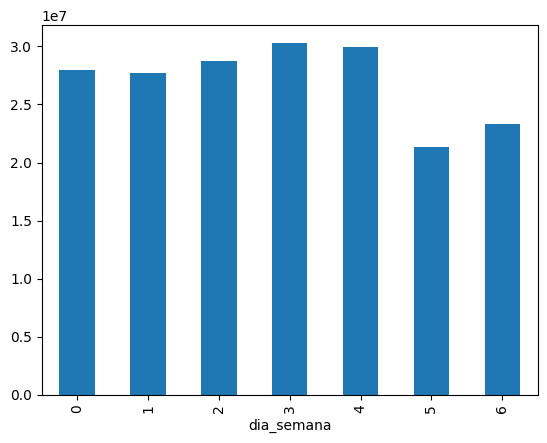

In [70]:
df_treino.groupby('mes')['gmv_success'].sum().plot(kind='bar')
df_treino.groupby('dia_semana')['gmv_success'].sum().plot(kind='bar')

## Trechos e Concentração de Mercado

In [71]:
top_trechos = df_treino['trecho_ida'].value_counts()
print(top_trechos)

trecho_ida
Cidade_0 -> Cidade_2          26219
Cidade_2 -> Cidade_0          24974
Cidade_0 -> Cidade_65         14752
Cidade_0 -> Cidade_5          13787
Cidade_5 -> Cidade_0          12400
                              ...  
Cidade_748 -> Cidade_63           1
Cidade_499 -> Cidade_804          1
Cidade_2007 -> Cidade_1042        1
Cidade_367 -> Cidade_753          1
Cidade_1711 -> Cidade_97          1
Name: count, Length: 29326, dtype: int64


In [72]:
market_share = df_treino['empresa_ida'].value_counts(normalize=True).head(10) * 100
fidelidade = df_treino['mesma_empresa_ida_volta'].value_counts(normalize=True)
print(market_share)
print('\n')
print(fidelidade)

empresa_ida
Empresa_8     11.054862
Empresa_24     5.660952
Empresa_13     4.981977
Empresa_6      4.839972
Empresa_2      4.437348
Empresa_12     2.949254
Empresa_23     2.870426
Empresa_17     2.570352
Empresa_3      2.563515
Empresa_11     2.385844
Name: proportion, dtype: float64


mesma_empresa_ida_volta
0    0.906514
1    0.093486
Name: proportion, dtype: float64


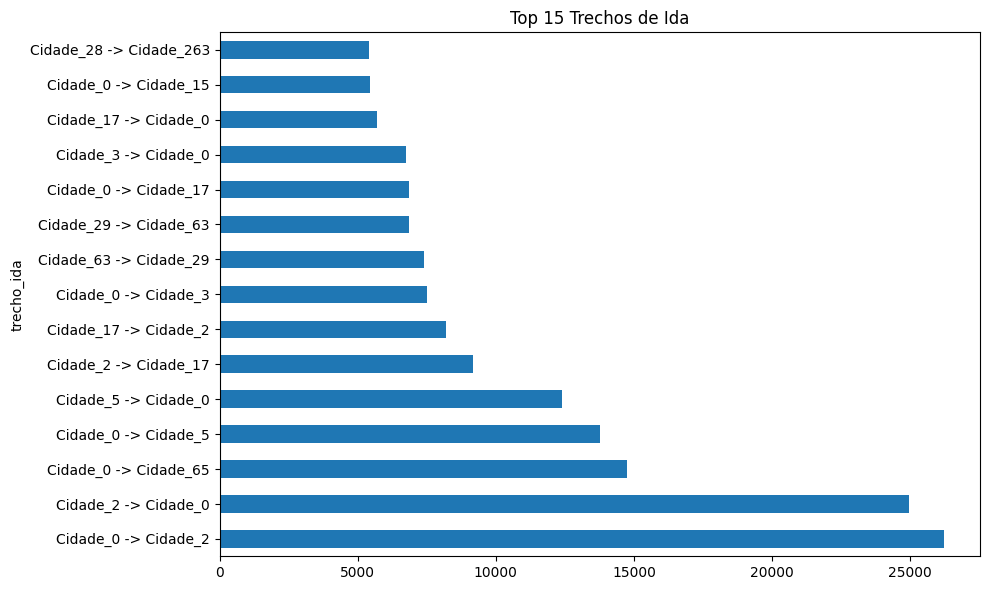

Trechos que respondem por 80% das vendas: 2209 de 29326


In [73]:
top_trechos = df_treino['trecho_ida'].value_counts().head(15)
top_trechos.plot(kind='barh', figsize=(10,6), title='Top 15 Trechos de Ida')
plt.tight_layout(); plt.show()

# Concentração: Regra de Pareto
trechos_freq = df_treino['trecho_ida'].value_counts(normalize=True).cumsum()
n_trechos_80 = (trechos_freq <= 0.80).sum()
print(f"Trechos que respondem por 80% das vendas: {n_trechos_80} de {trechos_freq.shape[0]}")

pop_map = df_treino['trecho_ida'].value_counts()

df_treino['popularidade_trecho'] = df_treino['trecho_ida'].map(pop_map)
df_val['popularidade_trecho']   = df_val['trecho_ida'].map(pop_map).fillna(0)
df_teste['popularidade_trecho'] = df_teste['trecho_ida'].map(pop_map).fillna(0)

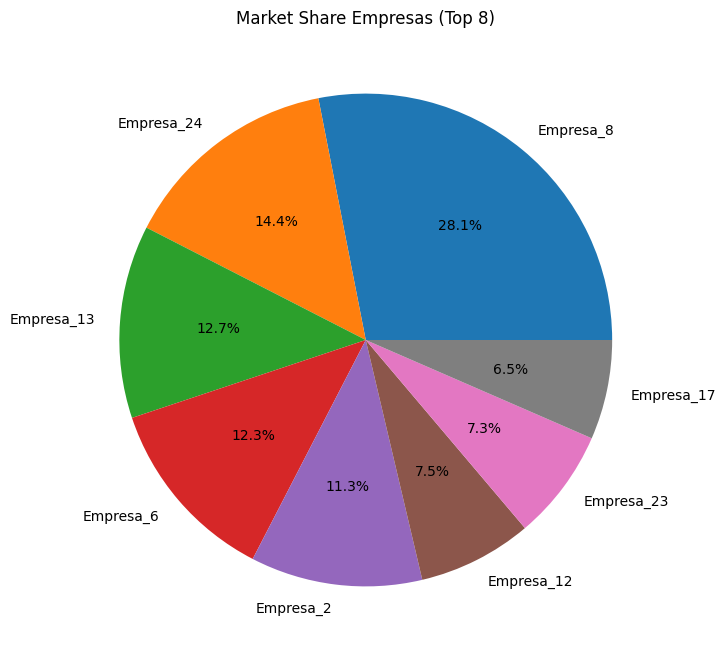

Clientes que usam mesma empresa ida e volta: 9.3%


In [74]:
# Market share top 8
market_share = df_treino['empresa_ida'].value_counts(normalize=True).head(8) * 100
market_share.plot(kind='pie', autopct='%1.1f%%', figsize=(8,8),
                  title='Market Share Empresas (Top 8)')
plt.ylabel(''); plt.show()

# Fidelidade ida/volta
fidelidade_rate = df_treino['mesma_empresa_ida_volta'].mean() * 100
print(f"Clientes que usam mesma empresa ida e volta: {fidelidade_rate:.1f}%")

In [75]:
gmv_empresa = df_treino.groupby('empresa_ida')['gmv_success'].agg(['mean','count','sum'])
gmv_empresa.columns = ['gmv_medio', 'n_vendas', 'gmv_total']
print(gmv_empresa.sort_values('gmv_total', ascending=False).head(10))

              gmv_medio  n_vendas     gmv_total
empresa_ida                                    
Empresa_8    130.927388    134210  1.757176e+07
Empresa_24   156.098834     68726  1.072805e+07
Empresa_6    168.450540     58759  9.897985e+06
Empresa_2    180.146509     53871  9.704673e+06
Empresa_13   133.141527     60483  8.052799e+06
Empresa_23   221.988419     34848  7.735852e+06
Empresa_17   214.373737     31205  6.689532e+06
Empresa_5    257.984722     23143  5.970540e+06
Empresa_11   205.738884     28965  5.959227e+06
Empresa_19   243.572638     20234  4.928449e+06


In [76]:
covid_resumo = df_treino.groupby('periodo_covid').agg(
    gmv_total    = ('gmv_success', 'sum'),
    gmv_medio    = ('gmv_success', 'mean'),
    n_compras    = ('gmv_success', 'count'),
    ticket_medio = ('quantidade_tickets', 'mean')
).round(2)
print(covid_resumo)

                  gmv_total  gmv_medio  n_compras  ticket_medio
periodo_covid                                                  
durante-covid  1.109641e+08     156.08     710966          1.38
pre-covid      7.841216e+07     155.87     503070          1.41


**Observação:** Devico o corte temporal para separação dos dados, o período pós covid não foi imputado dentro da base de treino

## Temporal

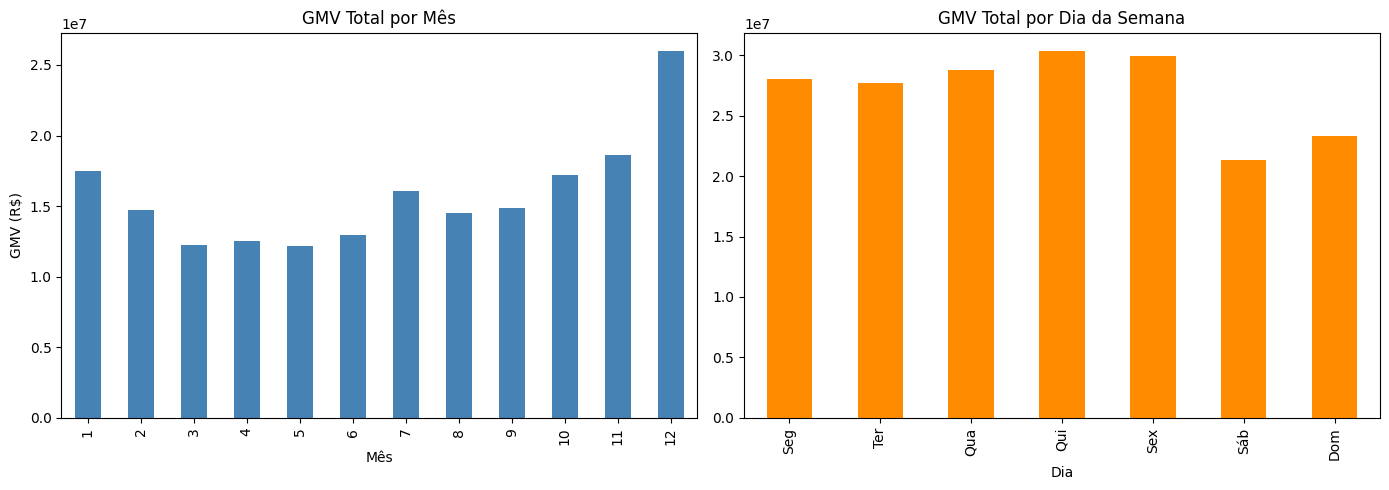

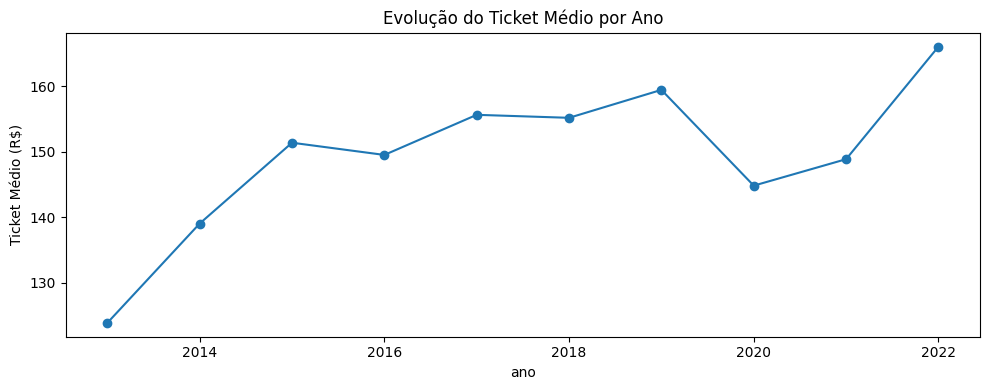

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gmv_mes = df_treino.groupby('mes')['gmv_success'].sum()
gmv_mes.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('GMV Total por Mês')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('GMV (R$)')

gmv_dia = df_treino.groupby('dia_semana')['gmv_success'].sum()
gmv_dia.index = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
gmv_dia.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('GMV Total por Dia da Semana')
axes[1].set_xlabel('Dia')

plt.tight_layout(); plt.show()

ticket_ano = df_treino.groupby('ano')['gmv_success'].mean()
ticket_ano.plot(marker='o', figsize=(10, 4), title='Evolução do Ticket Médio por Ano')
plt.ylabel('Ticket Médio (R$)'); plt.tight_layout(); plt.show()

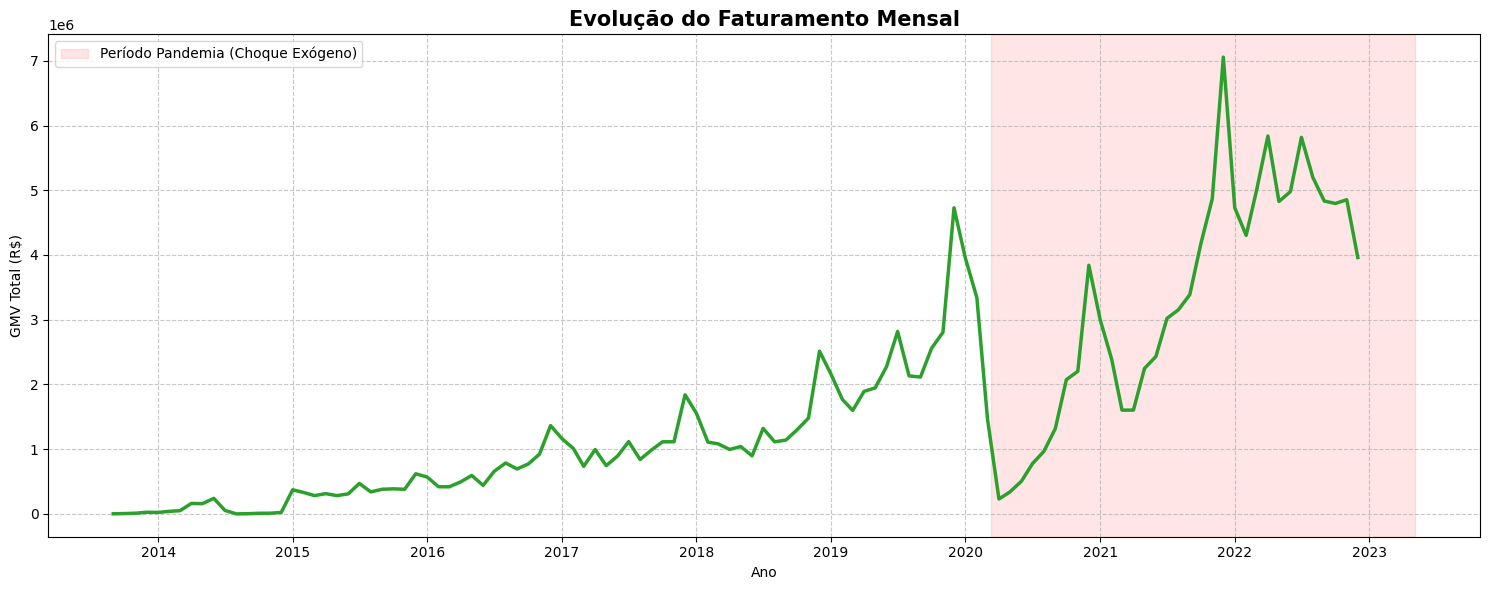

In [78]:
from src.utils import INICIO_COVID, FIM_COVID

gmv_mensal_cont = df_treino.groupby(df_treino['data_compra'].dt.to_period('M'))['gmv_success'].sum().reset_index()
gmv_mensal_cont['data_compra'] = gmv_mensal_cont['data_compra'].dt.to_timestamp()

plt.figure(figsize=(15,6))
sns.lineplot(data=gmv_mensal_cont, x='data_compra', y='gmv_success', linewidth=2.5, color='#2ca02c')

plt.axvspan(INICIO_COVID, FIM_COVID, color='red', alpha=0.1, label='Período Pandemia (Choque Exógeno)')

plt.title('Evolução do Faturamento Mensal', fontweight='bold', fontsize=15)
plt.xlabel('Ano')
plt.ylabel('GMV Total (R$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

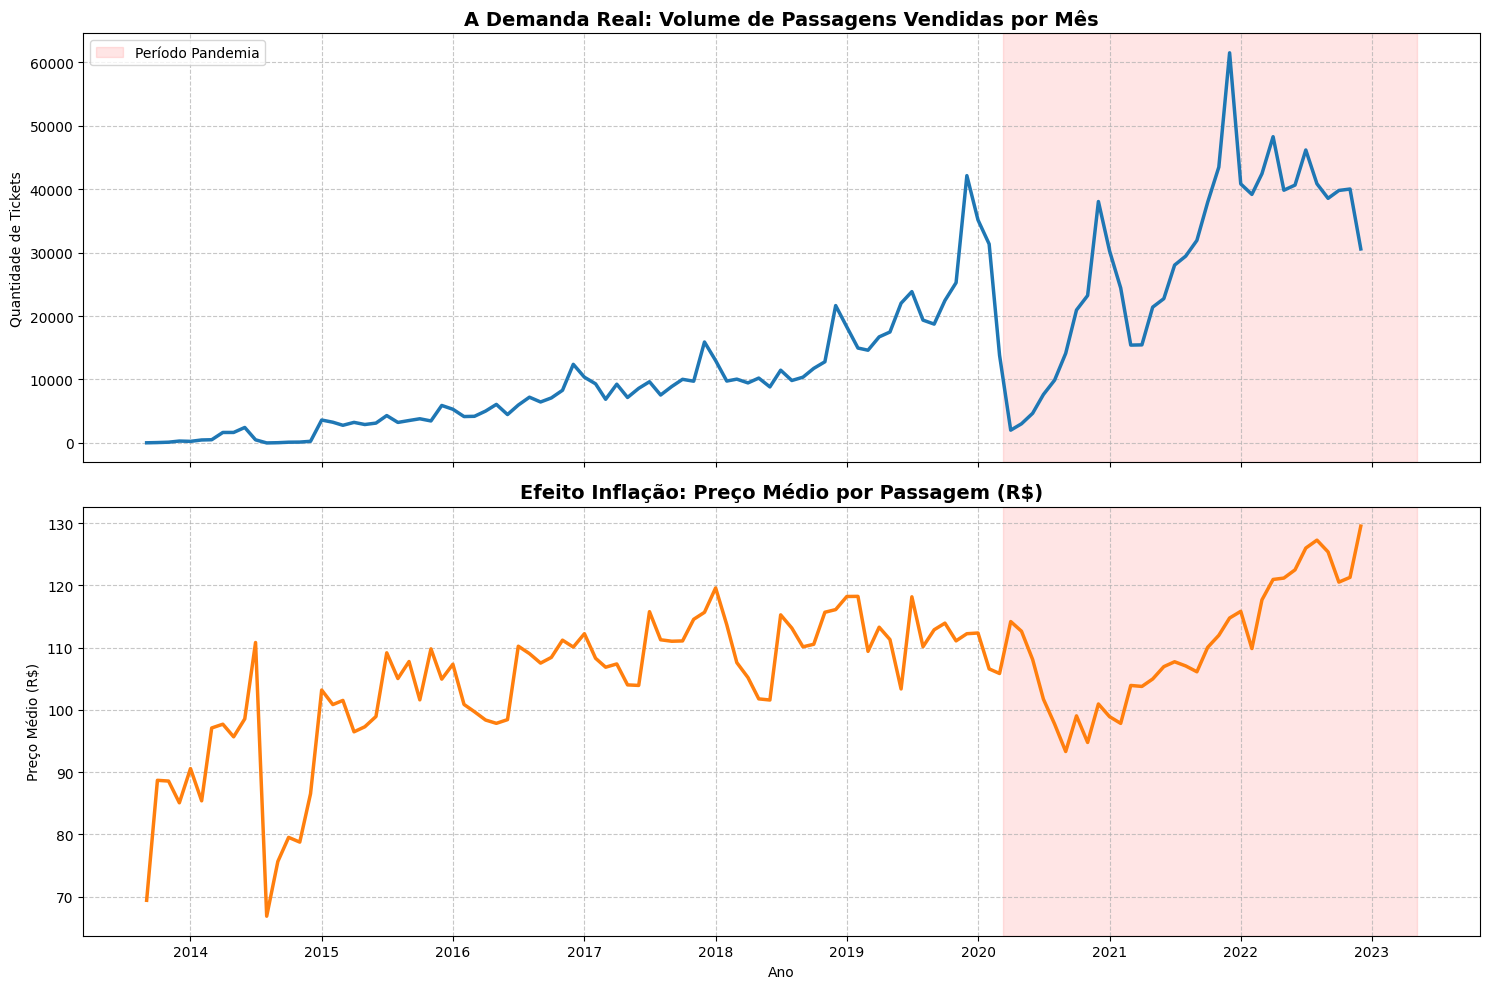

In [79]:
evolucao_mensal = df_treino.groupby(df_treino['data_compra'].dt.to_period('M')).agg(
    gmv_total=('gmv_success', 'sum'),
    tickets_totais=('quantidade_tickets', 'sum')
).reset_index()

evolucao_mensal['data_compra'] = evolucao_mensal['data_compra'].dt.to_timestamp()
evolucao_mensal['preco_medio_passagem'] = evolucao_mensal['gmv_total'] / evolucao_mensal['tickets_totais']

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Volume de passagens
sns.lineplot(data=evolucao_mensal, x='data_compra', y='tickets_totais', ax=axes[0], color='#1f77b4', linewidth=2.5)
axes[0].axvspan(INICIO_COVID, FIM_COVID, color='red', alpha=0.1, label='Período Pandemia')
axes[0].set_title('A Demanda Real: Volume de Passagens Vendidas por Mês', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Quantidade de Tickets')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Preço médio ao decorrer do tempo
sns.lineplot(data=evolucao_mensal, x='data_compra', y='preco_medio_passagem', ax=axes[1], color='#ff7f0e', linewidth=2.5)
axes[1].axvspan(INICIO_COVID, FIM_COVID, color='red', alpha=0.1)
axes[1].set_title('Efeito Inflação: Preço Médio por Passagem (R$)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Preço Médio (R$)')
axes[1].set_xlabel('Ano')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [80]:
df_treino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214036 entries, 0 to 1214035
Data columns (total 30 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   nk_ota_localizer_id        1214036 non-null  object        
 1   data_compra                1214036 non-null  datetime64[ns]
 2   time_purchase              1214036 non-null  object        
 3   gmv_success                1214036 non-null  float64       
 4   quantidade_tickets         1214036 non-null  int16         
 5   origem_ida                 1214036 non-null  object        
 6   destino_ida                1214036 non-null  object        
 7   origem_volta               1214036 non-null  object        
 8   destino_volta              1214036 non-null  object        
 9   empresa_ida                1214036 non-null  object        
 10  empresa_volta              1214036 non-null  object        
 11  id_cliente                 1214036 no

In [81]:
var_num = df_treino.select_dtypes(include=['int8', 'int16', 'int32', 'int64', 'float16', 'float32', 'float64']).columns.tolist()
var_cat = df_treino.select_dtypes(include=['object', 'category']).columns.tolist()
var_data = df_treino.select_dtypes(include=['datetime64']).columns.tolist()

print(f'Variaveis numéricas: ({len(var_num)}): {var_num}')
print(f'Variáveis categóricas: ({len(var_cat)}: {var_cat}')
print(f'Variáveis de data: ({len(var_data)}: {var_data}')

Variaveis numéricas: (13): ['gmv_success', 'quantidade_tickets', 'ano', 'mes', 'dia', 'dia_semana', 'fim_de_semana', 'e_feriado', 'compra_ate_5_dias_feriado', 'hora_compra', 'mesma_empresa_ida_volta', 'mesmo_trecho_ida_volta', 'popularidade_trecho']
Variáveis categóricas: (16: ['nk_ota_localizer_id', 'time_purchase', 'origem_ida', 'destino_ida', 'origem_volta', 'destino_volta', 'empresa_ida', 'empresa_volta', 'id_cliente', 'periodo_covid', 'periodo_compra', 'trecho_ida', 'trecho_volta_valido', 'combinacao_empresa', 'faixa_tickets', 'split']
Variáveis de data: (1: ['data_compra']


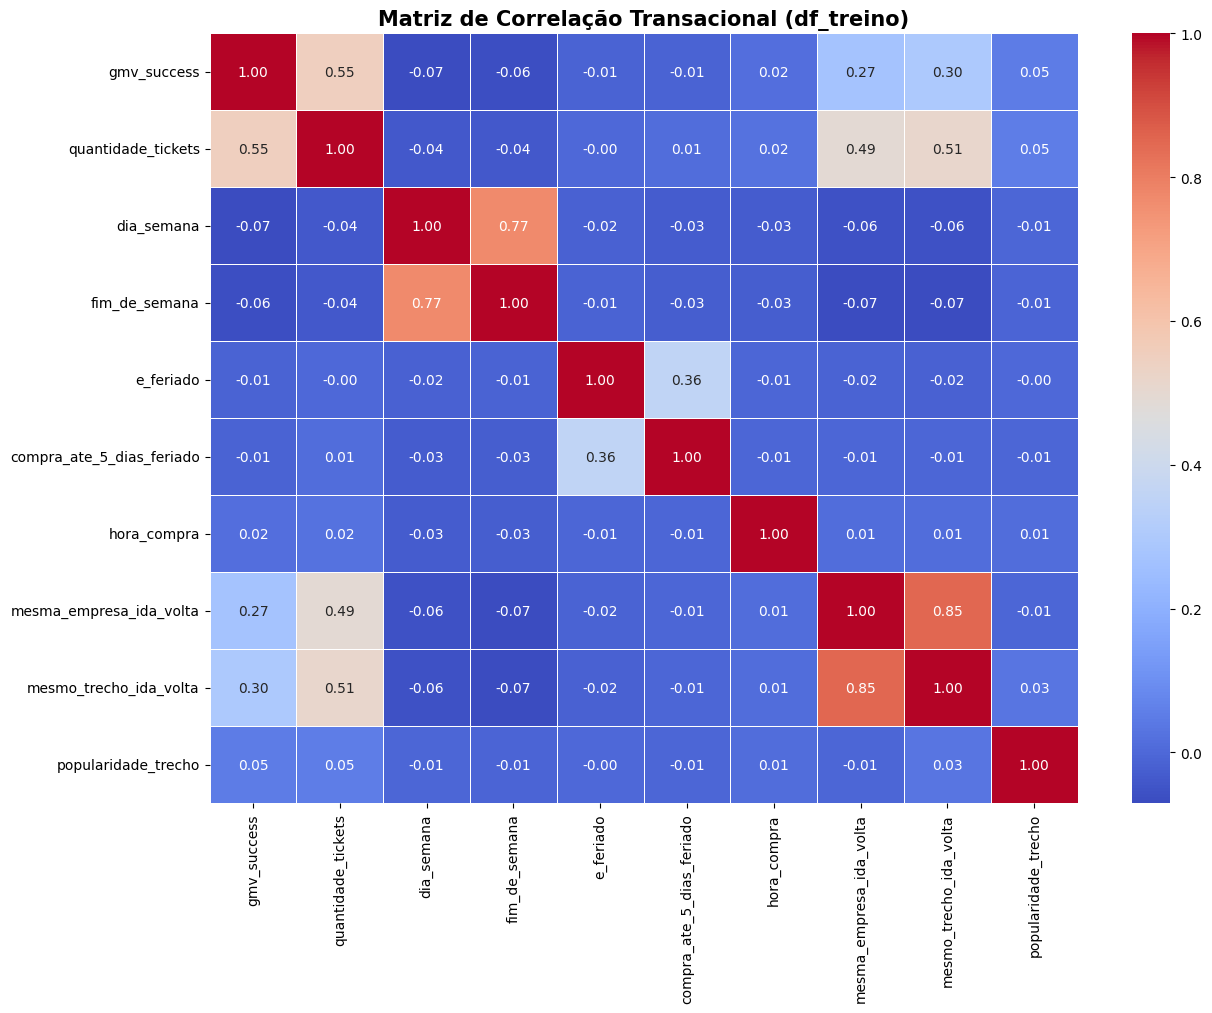

In [82]:
col_exc = ['ano', 'mes', 'dia']
col_corr = [col for col in var_num if col not in col_exc]

corr_matrix = df_treino[col_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação Transacional (df_treino)', fontweight='bold', fontsize=15)
plt.show()

# # Construção do `df_cliente` — Feature Engineering por Agente Econômico

Criação de um df relacionado ao cliente com as variáveis que mais podem ser úteis, separando em monetário, frequência, recência, comportamento turístico

In [83]:
data_ref = df_treino['data_compra'].max()

df_cliente = df_treino.groupby('id_cliente').agg(
    gmv_total = ('gmv_success', 'sum'),
    gmv_medio = ('gmv_success', 'mean'),

    total_compras = ('gmv_success', 'count'),
    tickets_total = ('quantidade_tickets', 'sum'),
    tickets_medio = ('quantidade_tickets', 'mean'),

    primeira_compra = ('data_compra', 'min'),
    ultima_compra = ('data_compra', 'max'),

    n_destinos_distintos = ('destino_ida', 'nunique'),
    n_empresas_distintas = ('empresa_ida', 'nunique'),
    compras_feriado = ('compra_ate_5_dias_feriado', 'sum'),
    comprou_volta = ('mesmo_trecho_ida_volta', 'sum'),
    prop_fim_semana = ('fim_de_semana', 'mean'),
    pop_trecho_media = ('popularidade_trecho', 'mean'),

    periodo_covid_max = ('periodo_covid', lambda x: x.mode()[0] if not x.mode().empty else 'N/A')
).reset_index()

In [84]:
df_cliente['recencia_dias'] = (
    data_ref - df_cliente['ultima_compra']
).dt.days

df_cliente['tempo_vida_dias'] = (
    df_cliente['ultima_compra'] - df_cliente['primeira_compra']
).dt.days

#  Flag recorrente
df_cliente['recorrente'] = (df_cliente['total_compras'] > 1).astype(int)

# Proporção de compras em feriado (relativa ao total)
df_cliente['prop_feriado'] = (
    df_cliente['compras_feriado'] / df_cliente['total_compras']
).round(4)

# Proporção de viagens com volta
df_cliente['prop_ida_volta'] = (
    df_cliente['comprou_volta'] / df_cliente['total_compras']
).round(4)

In [85]:
fidelidade_empresa = (
    df_treino.groupby(['id_cliente', 'empresa_ida'])['gmv_success'].sum()
    .reset_index()
)
gmv_total_cliente = df_treino.groupby('id_cliente')['gmv_success'].sum()
fidelidade_empresa['gmv_total'] = fidelidade_empresa['id_cliente'].map(gmv_total_cliente)
fidelidade_empresa['score'] = fidelidade_empresa['gmv_success'] / fidelidade_empresa['gmv_total']

score_fidelidade = fidelidade_empresa.groupby('id_cliente')['score'].max().reset_index()
score_fidelidade.columns = ['id_cliente', 'score_fidelidade']

df_cliente = df_cliente.merge(score_fidelidade, on='id_cliente', how='left')

In [86]:
print(f"Shape: {df_cliente.shape}")
print(f"Clientes únicos: {len(df_cliente):,}")
print(f"\nTipos:")
print(df_cliente.dtypes.value_counts())

print(f"\nNulos:")
nulos = df_cliente.isnull().sum()
nulos = nulos[nulos > 0]
if len(nulos):
    print(nulos)
else:
    print("Nenhum nulo encontrado")

Shape: (462800, 21)
Clientes únicos: 462,800

Tipos:
float64           8
int64             8
object            2
datetime64[ns]    2
int16             1
Name: count, dtype: int64

Nulos:
Nenhum nulo encontrado


In [87]:
df_cliente.select_dtypes(include=np.number).describe().T.style \
    .format("{:.2f}") \
    .background_gradient(subset=['mean', '50%'])

,count,mean,std,min,25%,50%,75%,max
gmv_total,462800.00,409.20,1309.05,4.19,108.17,209.89,433.12,307870.82
gmv_medio,462800.00,174.41,157.99,4.19,78.12,132.55,215.48,4786.61
total_compras,462800.00,2.62,6.47,1.00,1.00,1.00,2.00,1200.00
tickets_total,462800.00,3.65,9.31,1.00,1.00,2.00,4.00,1977.00
tickets_medio,462800.00,1.48,0.84,1.00,1.00,1.00,2.00,12.00
n_destinos_distintos,462800.00,1.60,1.22,1.00,1.00,1.00,2.00,111.00
n_empresas_distintas,462800.00,1.45,1.07,1.00,1.00,1.00,2.00,71.00
compras_feriado,462800.00,0.45,1.15,0.00,0.00,0.00,1.00,135.00
comprou_volta,462800.00,0.26,1.26,0.00,0.00,0.00,0.00,405.00
prop_fim_semana,462800.00,0.26,0.38,0.00,0.00,0.00,0.50,1.00


In [88]:
# validação sobre clientes recorrentes x comprasúnicas (One-Shot)

total = len(df_cliente)
recorrentes  = df_cliente['recorrente'].sum()
one_shot     = total - recorrentes

print(f"  One-Shot  (1 compra) : {one_shot:>8,}  ({one_shot/total:.1%})")
print(f"  Recorrentes (2+)     : {recorrentes:>8,}  ({recorrentes/total:.1%})")

comparativo = df_cliente.groupby('recorrente').agg(
    gmv_total_mediano     = ('gmv_total',      'median'),
    ticket_medio_mediano  = ('tickets_medio',   'median'),
    recencia_mediana      = ('recencia_dias',  'median'),
    destinos_medianos     = ('n_destinos_distintos', 'median'),
    fidelidade_mediana    = ('score_fidelidade','median'),
    prop_feriado_media    = ('prop_feriado',   'mean'),
).round(2)
comparativo.index = ['One-Shot', 'Recorrente']

print("\nPerfil Comparativo (Medianas):")
display(comparativo.T)


  One-Shot  (1 compra) :  266,944  (57.7%)
  Recorrentes (2+)     :  195,856  (42.3%)

Perfil Comparativo (Medianas):


,One-Shot,Recorrente
gmv_total_mediano,133.93,424.23
ticket_medio_mediano,1.00,1.17
recencia_mediana,804.00,398.00
destinos_medianos,1.00,2.00
fidelidade_mediana,1.00,0.77
prop_feriado_media,0.18,0.18


In [89]:
# média estatística que indica o grau de distorção (desvio) da simetria de uma distribuição em relação à sua média
skewness  = df_cliente.select_dtypes(include=np.number).skew().sort_values(ascending=False)

print(skewness.sort_values(ascending=False))

comprou_volta           103.401088
gmv_total               101.897050
tickets_total            77.264799
total_compras            57.846173
compras_feriado          22.372486
n_destinos_distintos     11.666520
n_empresas_distintas      8.299410
gmv_medio                 3.835703
tickets_medio             3.158533
pop_trecho_media          3.142320
tempo_vida_dias           2.837463
prop_ida_volta            2.410855
prop_feriado              1.730289
prop_fim_semana           1.112279
recencia_dias             0.888867
recorrente                0.310899
score_fidelidade         -1.644087
dtype: float64


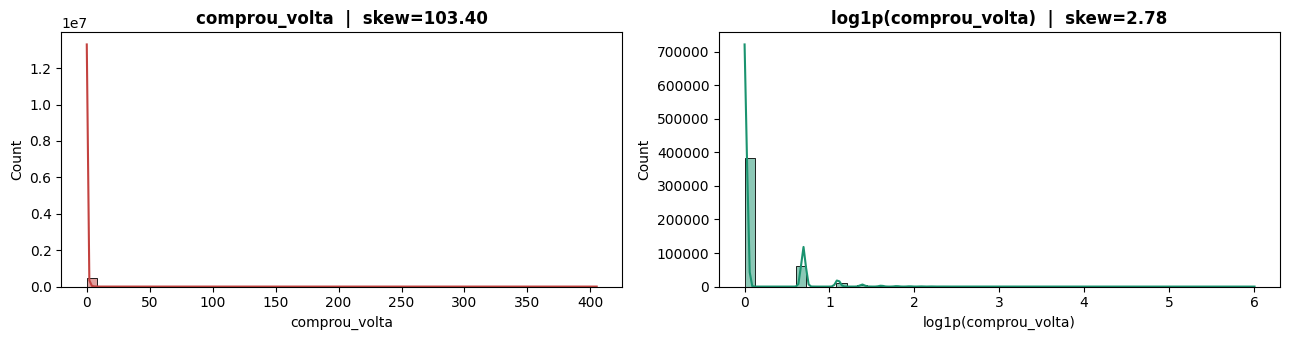

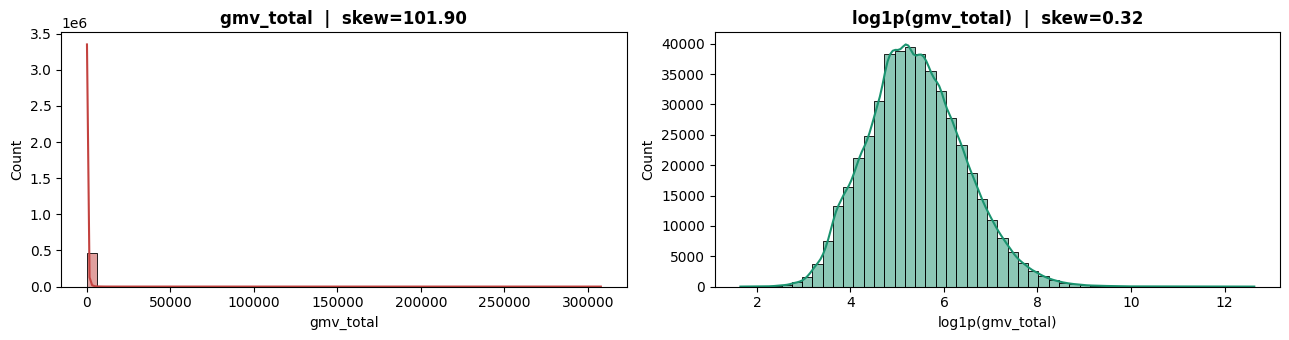

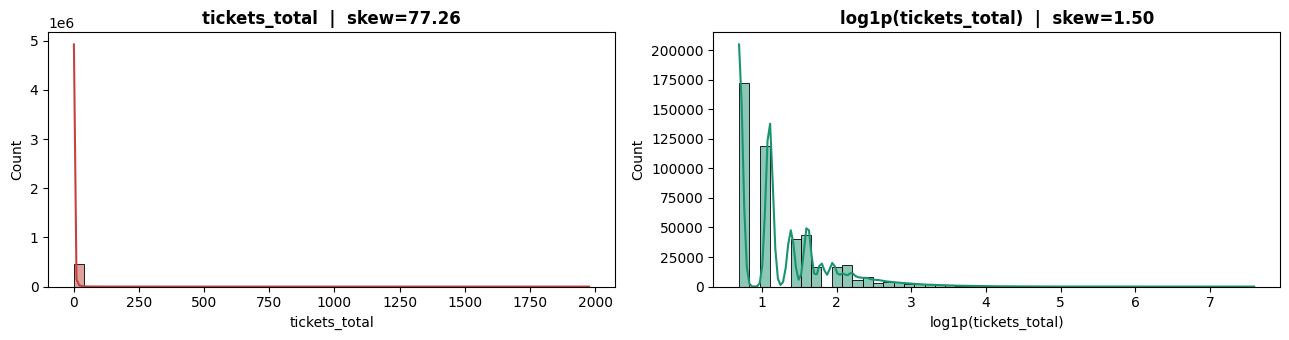

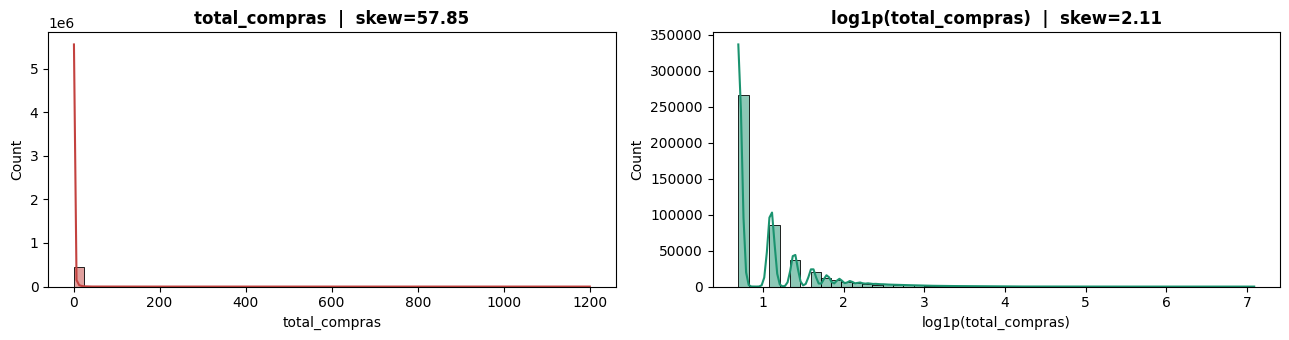

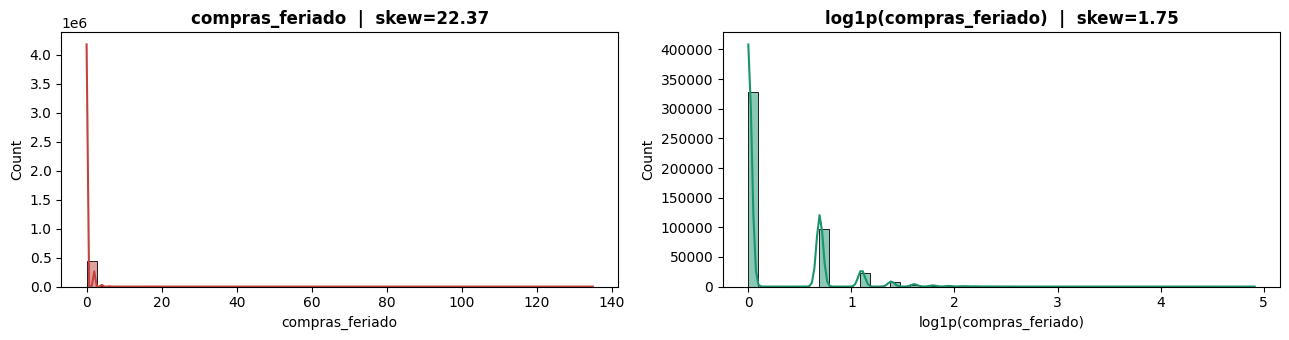

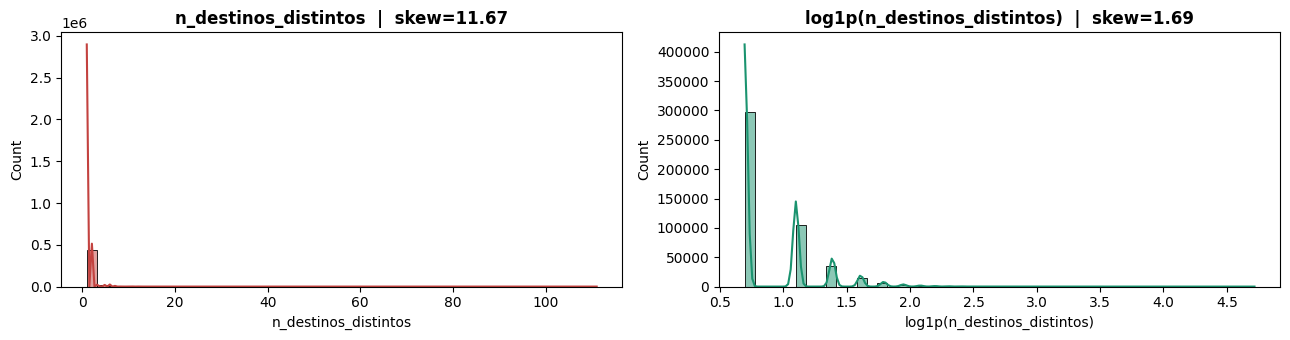

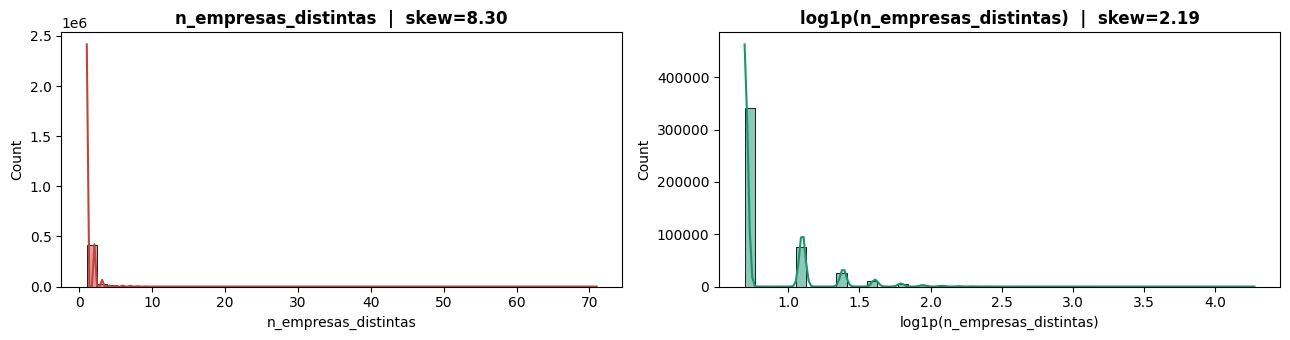

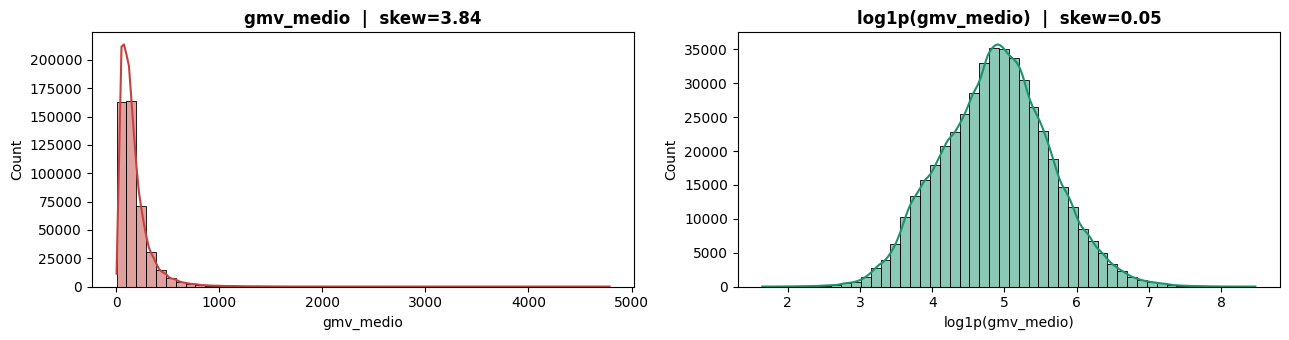

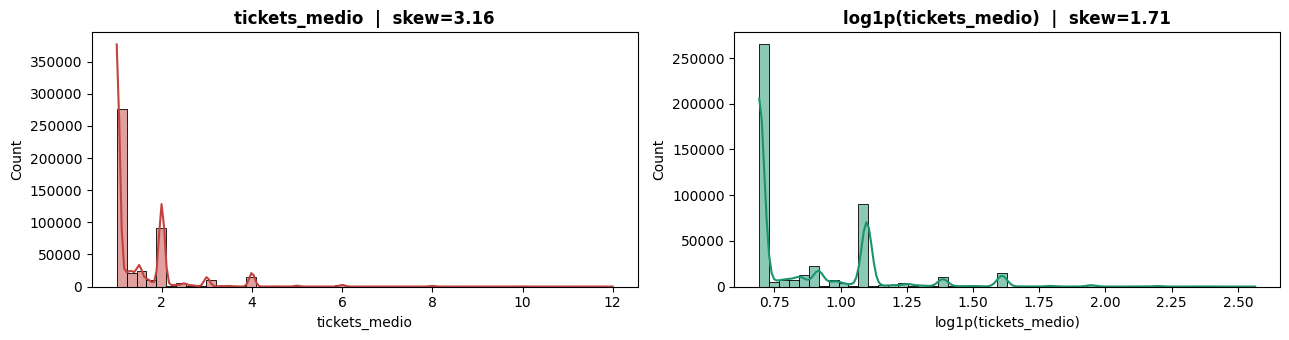

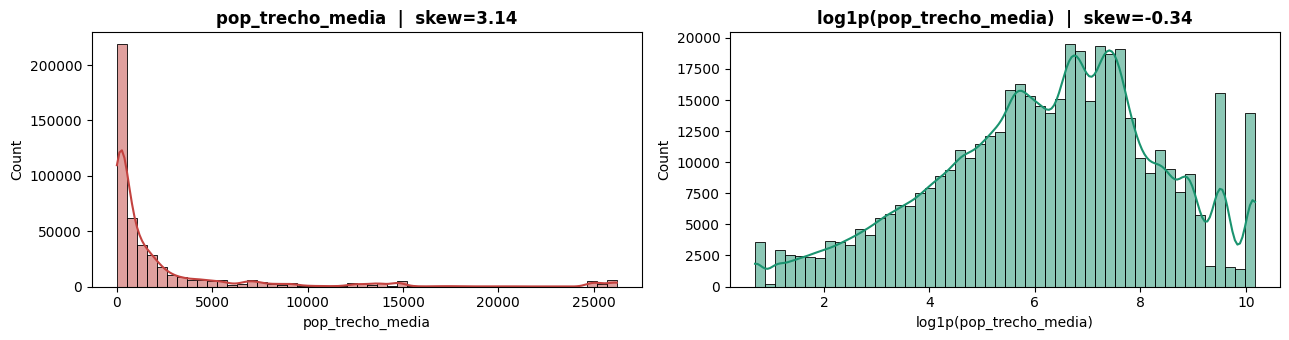

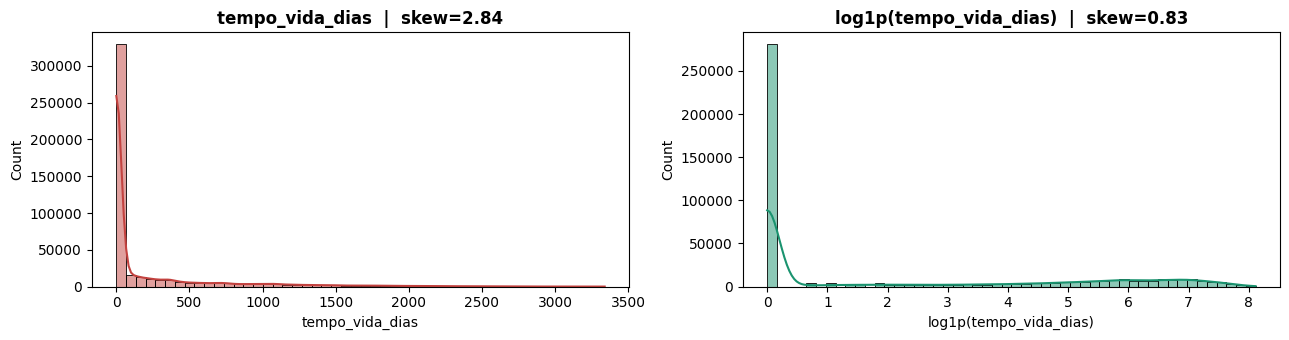

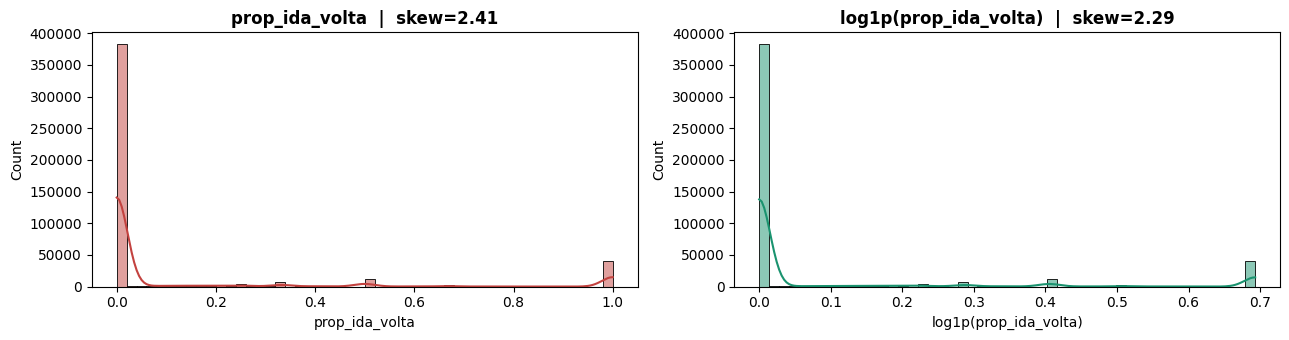

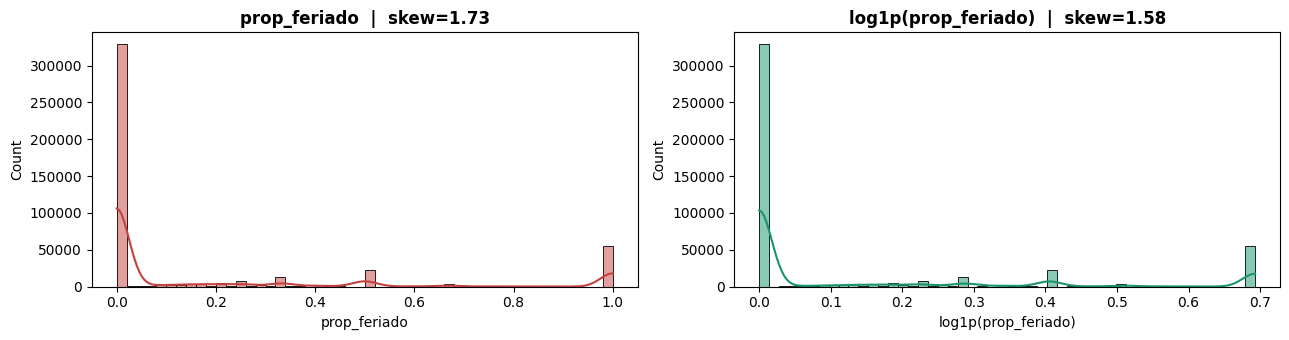

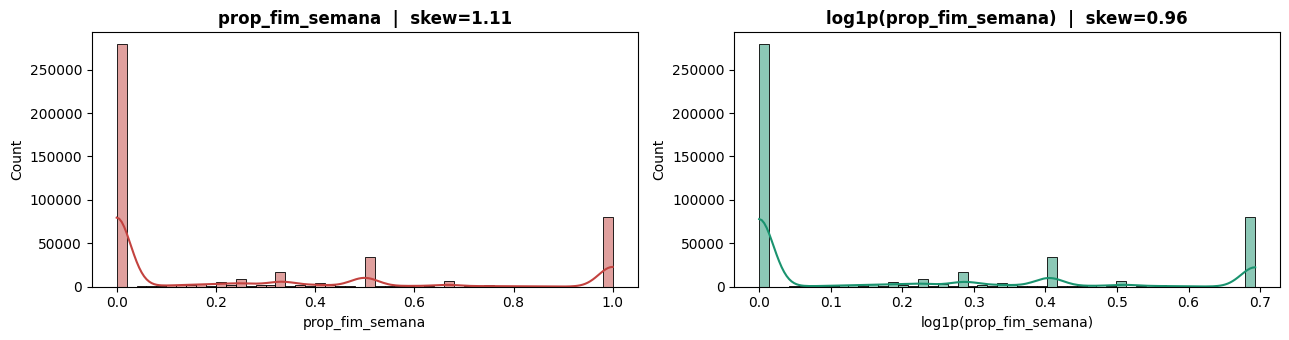

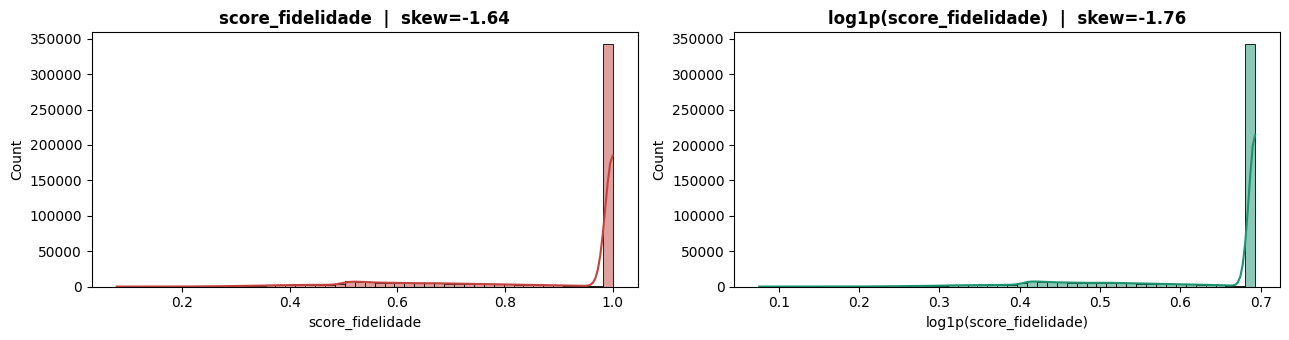

In [90]:
cols_dist = [c for c in skewness.index
             if abs(skewness[c]) > 1]

for col in cols_dist:
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

    # Original
    sns.histplot(df_cliente[col].dropna(), kde=True,
                 ax=axes[0], color='#C3423F', bins=50)
    axes[0].set_title(f"{col}  |  skew={df_cliente[col].skew():.2f}",
                      fontweight='bold')
    axes[0].set_xlabel(col)

    # log1p
    log_data = np.log1p(df_cliente[col].dropna())
    sns.histplot(log_data, kde=True,
                 ax=axes[1], color='#1A936F', bins=50)
    axes[1].set_title(f"log1p({col})  |  skew={log_data.skew():.2f}",
                      fontweight='bold')
    axes[1].set_xlabel(f"log1p({col})")

    plt.tight_layout()
    plt.show()

Distribuições com `|skew| > 1` indicam que a variável tem uma cauda longa — a maioria dos valores está concentrada próximo de zero, com poucos valores muito altos. Para algoritmos baseados em distância (K-Means), isso é crítico: um cliente com GMV de R$ 50.000 "puxa" o centróide do cluster, mesmo representando menos de 0.1% da base.

**Solução:** `log1p(x)` comprime a cauda sem perder a ordenação dos valores. O log transforma diferenças multiplicativas em aditivas — economicamente equivalente a trabalhar com **variações percentuais** em vez de valores absolutos. As versões `_log` das variáveis com alto skew serão usadas nos modelos.

In [91]:
# verificação de Outliers
relatorio = []

for col in skewness.index:
    serie = df_cliente[col].dropna()
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr    = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out  = ((serie < lo) | (serie > hi)).sum()
    pct    = n_out / len(serie) * 100
    relatorio.append({
        'feature'    : col,
        'n_outliers' : n_out,
        'pct_%'      : round(pct, 2),
        'lim_inf'    : round(lo, 2),
        'lim_sup'    : round(hi, 2),
        'max_real'   : round(serie.max(), 2),
    })

df_out = pd.DataFrame(relatorio).sort_values('pct_%', ascending=False)
display(df_out)

,feature,n_outliers,pct_%,lim_inf,lim_sup,max_real
16,score_fidelidade,91279,19.72,0.74,1.16,1.00
10,tempo_vida_dias,81584,17.63,-214.50,357.50,3339.00
0,comprou_volta,80432,17.38,0.00,0.00,405.00
11,prop_ida_volta,80432,17.38,0.00,0.00,1.00
3,total_compras,73213,15.82,-0.50,3.50,1200.00
9,pop_trecho_media,64034,13.84,-2841.50,5082.50,26219.00
12,prop_feriado,61508,13.29,-0.30,0.50,1.00
1,gmv_total,41487,8.96,-379.25,920.54,307870.82
2,tickets_total,36033,7.79,-3.50,8.50,1977.00
7,gmv_medio,27786,6.00,-127.92,421.52,4786.61


### Correlação

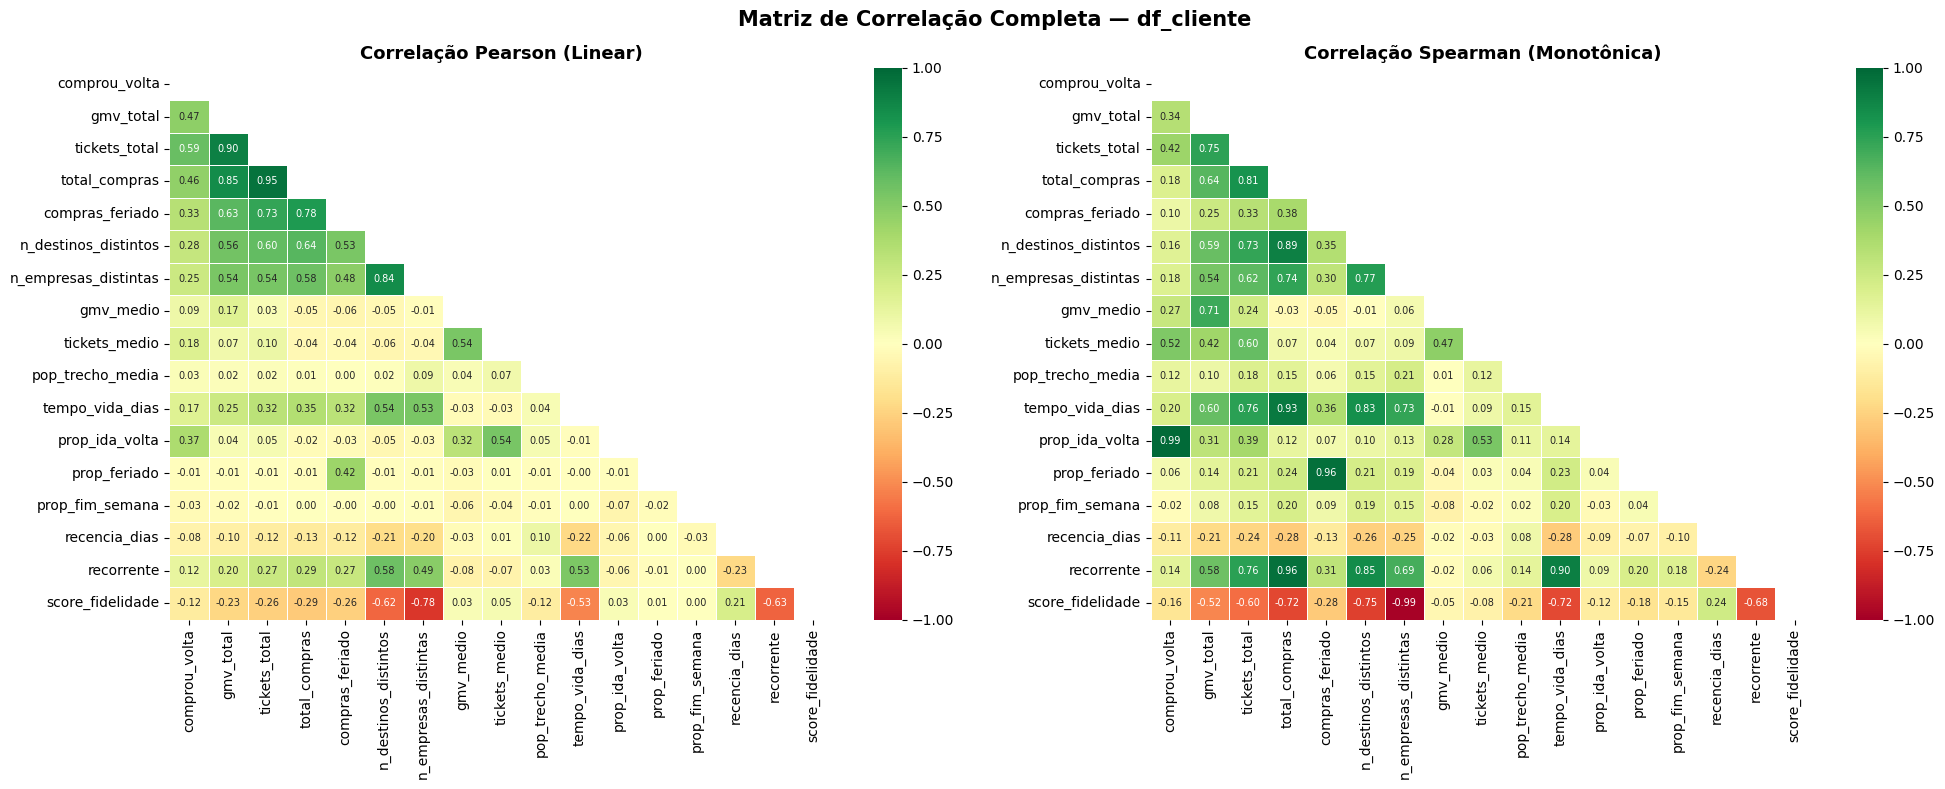

In [92]:
# validação por correlação e identificação de variáveis que fazem mais sentidos
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, method, titulo in zip(
    axes,
    ['pearson', 'spearman'],
    ['Pearson (Linear)', 'Spearman (Monotônica)']
):
    corr = df_cliente[skewness.index].corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
                cmap='RdYlGn', center=0, ax=ax,
                linewidths=0.4, vmin=-1, vmax=1,
                annot_kws={"size": 7})
    ax.set_title(f"Correlação {titulo}", fontsize=13, fontweight='bold')

plt.suptitle("Matriz de Correlação Completa — df_cliente",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Diagnóstico de Multicolinearidade — Variance Inflation Factor (VIF)

O VIF mede o quanto a variância de um coeficiente é inflada pela correlação com outras variáveis. Para modelos lineares, VIF > 10 é um problema sério. Para clustering e árvores de decisão (XGBoost, LightGBM), o impacto é menor — mas features redundantes aumentam dimensionalidade sem ganho de informação.

In [93]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vif = df_cliente[skewness.index].dropna()

vif = pd.DataFrame({
    'feature': skewness.index,
    'VIF'    : [variance_inflation_factor(df_vif.values, i)
                for i in range(len(skewness.index))]
}).sort_values('VIF', ascending=False)

vif['status'] = vif['VIF'].apply(
    lambda v: " Remover"  if v > 10
    else      " Atenção"  if v > 5
    else      " OK"
)

print("VIF — Diagnóstico de Multicolinearidade:\n")
print(vif.to_string(index=False))

VIF — Diagnóstico de Multicolinearidade:

             feature       VIF   status
       tickets_total 37.514696  Remover
       total_compras 25.954884  Remover
n_destinos_distintos 12.977592  Remover
n_empresas_distintas 10.519119  Remover
       tickets_medio  9.981606  Atenção
           gmv_total  7.823216  Atenção
    score_fidelidade  7.455067  Atenção
     compras_feriado  5.940242  Atenção
           gmv_medio  3.788959       OK
          recorrente  2.974737       OK
       comprou_volta  2.607516       OK
       recencia_dias  2.544514       OK
        prop_feriado  2.505462       OK
      prop_ida_volta  2.079869       OK
     tempo_vida_dias  2.012588       OK
     prop_fim_semana  1.479979       OK
    pop_trecho_media  1.307576       OK


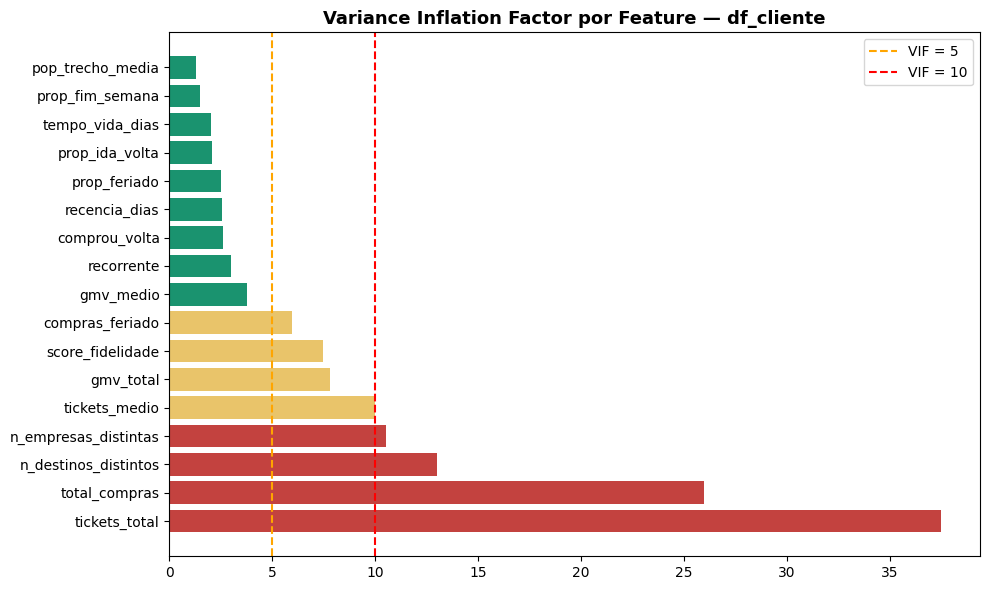

In [94]:
fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#C3423F' if v > 10 else '#E9C46A' if v > 5
         else '#1A936F' for v in vif['VIF']]
ax.barh(vif['feature'], vif['VIF'], color=cores)
ax.axvline(5,  color='orange', linestyle='--', lw=1.5, label='VIF = 5')
ax.axvline(10, color='red',    linestyle='--', lw=1.5, label='VIF = 10')
ax.set_title('Variance Inflation Factor por Feature — df_cliente', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [95]:
from scipy.stats import spearmanr

# pares selecionados visando a redução de redundância VIF
pares = [
    ('recencia_dias',      'gmv_total'),
    ('tempo_vida_dias',    'gmv_total'),
    ('ticket_medio',       'score_fidelidade'),
    ('n_destinos_distintos','score_fidelidade'),
    ('prop_feriado',       'gmv_total'),
    ('prop_fim_semana',    'gmv_total'),
    ('pop_trecho_media',   'ticket_medio'),
]

print("Análise de Spearman (Relações não-lineares):\n")
resultados = []

for c1, c2 in pares:
    if c1 in df_cliente.columns and c2 in df_cliente.columns:
        dados = df_cliente[[c1, c2]].dropna()
        r, p  = spearmanr(dados[c1], dados[c2])

        resultados.append({
            'Variavel_1': c1,
            'Variavel_2': c2,
            'Spearman_R': round(r, 4),
            'P_Valor'   : round(p, 6),
            'Força': 'Forte' if abs(r) > 0.7 else 'Moderada' if abs(r) > 0.4 else 'Fraca'
        })

df_spearman = pd.DataFrame(resultados).sort_values('Spearman_R', key=abs, ascending=False)
display(df_spearman)

Análise de Spearman (Relações não-lineares):



,Variavel_1,Variavel_2,Spearman_R,P_Valor,Força
2,n_destinos_distintos,score_fidelidade,-0.7492,0.0,Forte
1,tempo_vida_dias,gmv_total,0.5993,0.0,Moderada
0,recencia_dias,gmv_total,-0.2149,0.0,Fraca
3,prop_feriado,gmv_total,0.1425,0.0,Fraca
4,prop_fim_semana,gmv_total,0.0846,0.0,Fraca


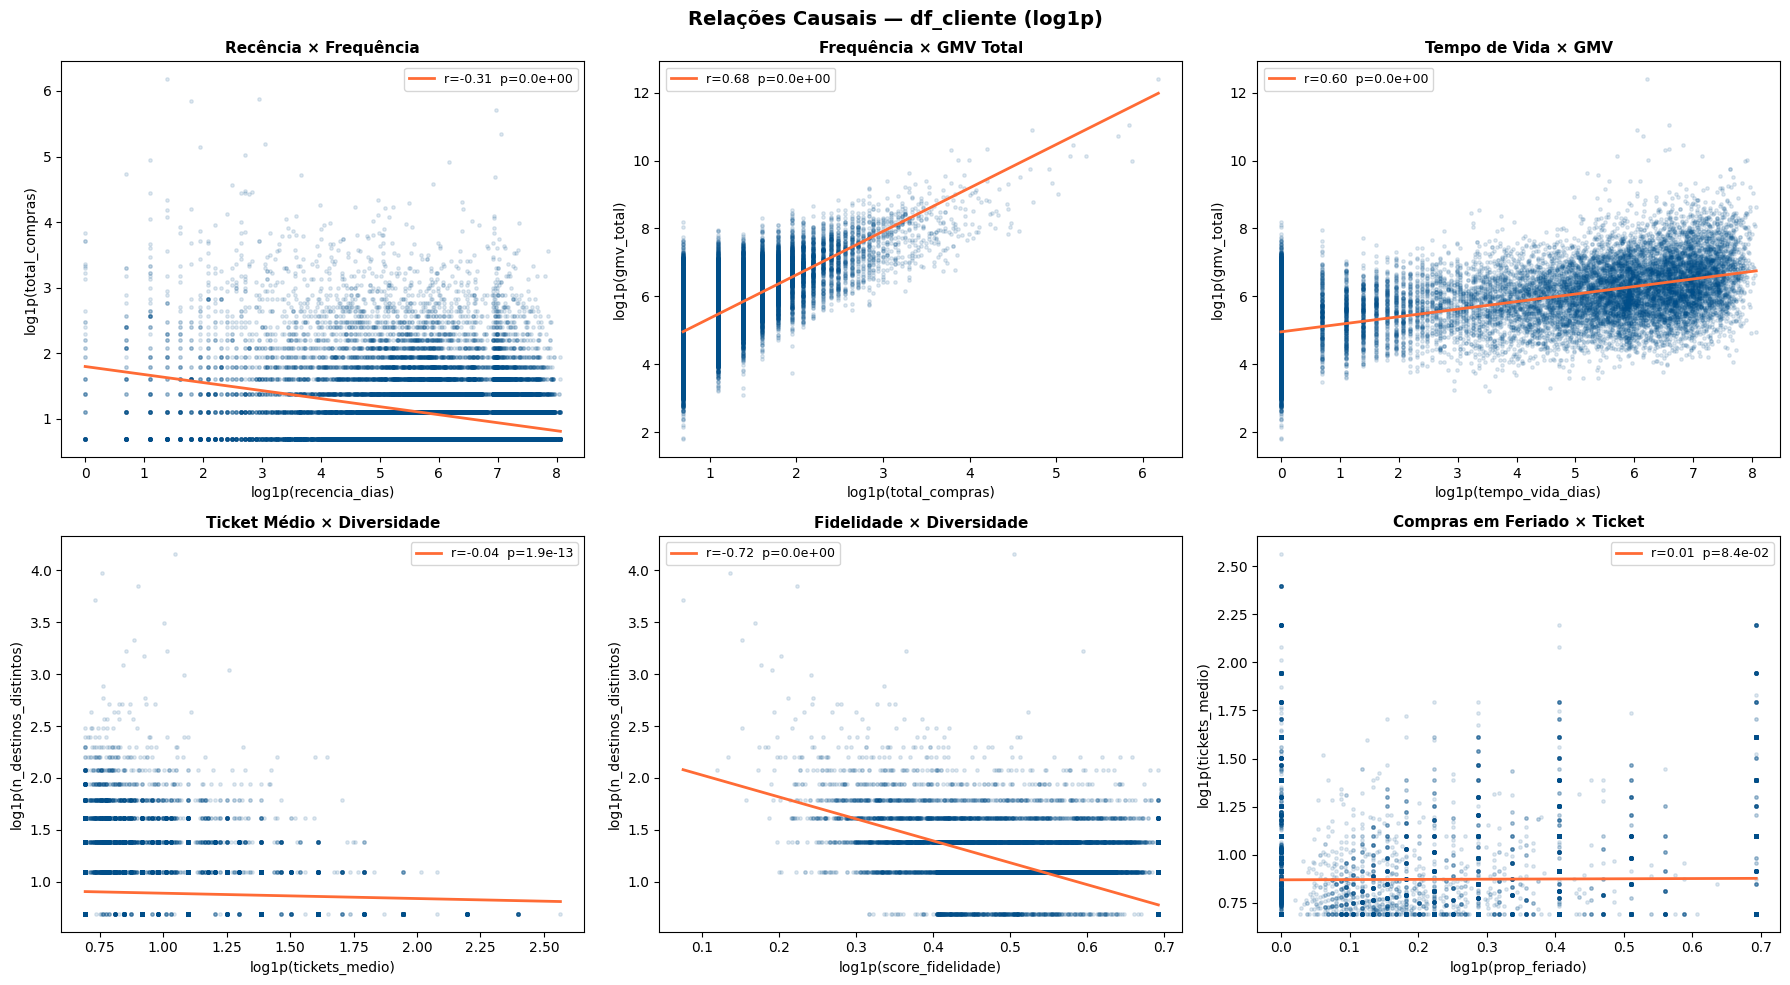

In [96]:
from scipy import stats

pares_scatter = [
    ('recencia_dias', 'total_compras',
     'Recência × Frequência'),
    ('total_compras', 'gmv_total',
     'Frequência × GMV Total'),
    ('tempo_vida_dias', 'gmv_total',
     'Tempo de Vida × GMV'),
    ('tickets_medio', 'n_destinos_distintos',
     'Ticket Médio × Diversidade'),
    ('score_fidelidade', 'n_destinos_distintos',
     'Fidelidade × Diversidade'),
    ('prop_feriado', 'tickets_medio',
     'Compras em Feriado × Ticket'),
]

df_s = df_cliente.sample(min(30_000, len(df_cliente)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (x, y, titulo) in enumerate(pares_scatter):
    xlog = np.log1p(df_s[x].fillna(0))
    ylog = np.log1p(df_s[y].fillna(0))

    axes[i].scatter(xlog, ylog, alpha=0.12, s=6, color='#004E89')

    m, b, r, p, _ = stats.linregress(xlog, ylog)
    xr = np.linspace(xlog.min(), xlog.max(), 100)
    axes[i].plot(xr, m*xr + b, color='#FF6B35', lw=2,
                 label=f'r={r:.2f}  p={p:.1e}')

    axes[i].set_title(titulo, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(f'log1p({x})')
    axes[i].set_ylabel(f'log1p({y})')
    axes[i].legend(fontsize=9)

plt.suptitle('Relações Causais — df_cliente (log1p)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Seleção Final de Features — Construção do `df_cliente` Definitivo

**Decisão de remoção baseada no VIF:**

Para cada par com VIF alto, a decisão seguiu o princípio de **manter a variável com maior informação econômica independente**:

- `gmv_medio` removido → `gmv_total` retido: o total acumulado captura melhor o valor histórico do cliente. A média é implicitamente recuperada dividindo pelo `total_compras`.
- `tickets_total` removido → `tickets_medio` retido: o comportamento *típico* por compra é mais informativo para segmentação do que o volume bruto.
- `n_empresas_distintas` removido → `score_fidelidade` retido: o score já captura concentração de empresa de forma contínua e mais interpretável.
- `compras_feriado` (contagem absoluta) removida → `prop_feriado` retida: a proporção normaliza pelo total de compras, tornando clientes com 1 vs 50 compras comparáveis.
- `recorrente` (flag binária) removida → a informação está implícita em `total_compras > 1`.

In [97]:
# Remoção de variáveis para mitigar a multicolinearidade (var com correlação alta e colinearidade inversa)
cols_to_drop = [
    'gmv_medio',
    'tickets_total',
    'n_empresas_distintas',
    'compras_feriado',
    'comprou_volta',
    'recorrente'
]

df_cliente = df_cliente.drop(columns=cols_to_drop, errors='ignore')

cols_skewed = [
    'gmv_total', 'total_compras', 'n_destinos_distintos',
    'pop_trecho_media', 'tempo_vida_dias', 'recencia_dias'
]

# preservar colunas originais
for col in cols_skewed:
    if col in df_cliente.columns:
        df_cliente[f'{col}_log'] = np.log1p(df_cliente[col])

features_selec_cliente = [
    'id_cliente',
    'gmv_total_log',
    'total_compras_log',
    'recencia_dias_log',
    'tempo_vida_dias_log',
    'n_destinos_distintos_log',
    'pop_trecho_media_log',
    'score_fidelidade',
    'prop_fim_semana',
    'prop_feriado',
    'tickets_medio',
    'prop_ida_volta'
]

df_cluster = df_cliente[features_selec_cliente].dropna()

**Transformação log1p** — aplicada nas variáveis com `|skew| > 1` para normalizar distribuição sem perda de ordenação.

In [98]:
df_cliente.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462800 entries, 0 to 462799
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   id_cliente                462800 non-null  object        
 1   gmv_total                 462800 non-null  float64       
 2   total_compras             462800 non-null  int64         
 3   tickets_medio             462800 non-null  float64       
 4   primeira_compra           462800 non-null  datetime64[ns]
 5   ultima_compra             462800 non-null  datetime64[ns]
 6   n_destinos_distintos      462800 non-null  int64         
 7   prop_fim_semana           462800 non-null  float64       
 8   pop_trecho_media          462800 non-null  float64       
 9   periodo_covid_max         462800 non-null  object        
 10  recencia_dias             462800 non-null  int64         
 11  tempo_vida_dias           462800 non-null  int64         
 12  pr

In [99]:
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462800 entries, 0 to 462799
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                462800 non-null  object 
 1   gmv_total_log             462800 non-null  float64
 2   total_compras_log         462800 non-null  float64
 3   recencia_dias_log         462800 non-null  float64
 4   tempo_vida_dias_log       462800 non-null  float64
 5   n_destinos_distintos_log  462800 non-null  float64
 6   pop_trecho_media_log      462800 non-null  float64
 7   score_fidelidade          462800 non-null  float64
 8   prop_fim_semana           462800 non-null  float64
 9   prop_feriado              462800 non-null  float64
 10  tickets_medio             462800 non-null  float64
 11  prop_ida_volta            462800 non-null  float64
dtypes: float64(11), object(1)
memory usage: 42.4+ MB


## `df_cliente` e `df_cluster` — Fundação para os Três Modelos

O dataframe construído nesta camada é a entrada única dos três notebooks de modelagem:

In [100]:
import os

os.makedirs(f"{DRIVE_BASE}/ouro", exist_ok=True)

df_cliente.to_parquet(f"{DRIVE_BASE}/ouro/df_cliente.parquet", index=False, engine="pyarrow") # visão analítica, se necessário
df_cluster.to_parquet(f"{DRIVE_BASE}/ouro/df_cluster.parquet", index=False, engine="pyarrow") # visão com as features para clusterização